In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

 
# Buscamos el archivo en nuestra 
df = pd.read_csv('US_Top_50_Universities_2026.csv')
 


In [6]:
df = pd.read_csv('US_Top_50_Universities_2026.csv')
print(df.head())
print(df.columns)
df.info()
 


                               University_Name  National_Rank  Founded_Year  \
0  Massachusetts Institute of Technology (MIT)              1          1861   
1                          Columbia University              2          1754   
2                         Princeton University              3          1746   
3                          Stanford University              4          1891   
4           University of California, Berkeley              5          1868   

  Institution_Type State  Research_Impact_Score  Intl_Student_Ratio  \
0          Private    MA                  100.0                91.6   
1          Private    NY                   95.9                83.7   
2          Private    NJ                   99.0                70.0   
3          Private    CA                   99.5                73.5   
4           Public    CA                   98.9                70.6   

   Employment_Rate  
0             96.2  
1             92.1  
2             94.5  
3             

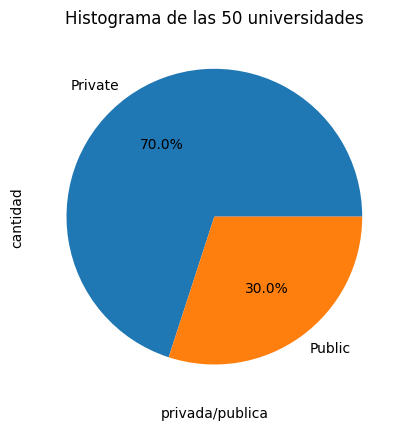

In [9]:
# Hagamos un primer histrograma para ver cuantas son publicas/privadas
plt.figure("Pie Chart")
plt.pie(df.Institution_Type.value_counts(),labels = df.Institution_Type.value_counts().index, autopct = '%1.1f%%' )
plt.title('Histograma de las 50 universidades')
plt.xlabel('privada/publica')
plt.ylabel('cantidad')
plt.show()
#Vemos que hay un ratio de 70% a 30%



C:\Users\Admin\AppData\Local\Temp\ipykernel_16412\2753585126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top5_estados.index, y=top5_estados.values, palette='magma', edgecolor='black')


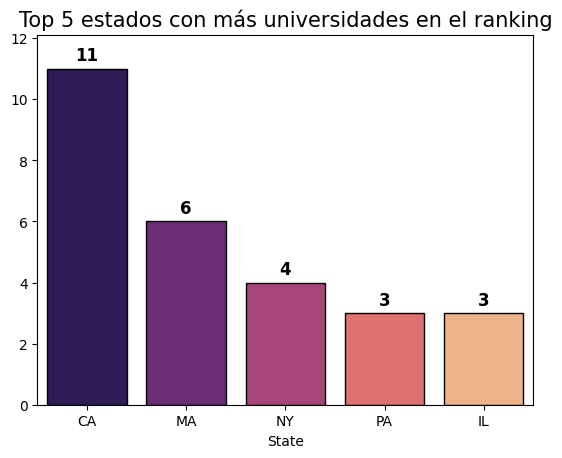

In [13]:
top5_estados = df['State'].value_counts().nlargest(5)
plt.figure("Top 5 estados con mas universidades")
ax = sns.barplot(x=top5_estados.index, y=top5_estados.values, palette='magma', edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=12, weight='bold')
plt.ylim(0, max(top5_estados.values) * 1.1)
plt.title('Top 5 estados con más universidades en el ranking', fontsize=15)
plt.show()

 

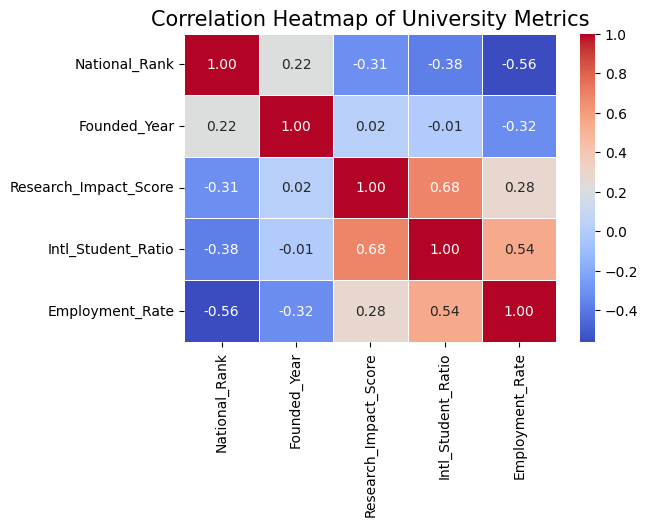

In [14]:
#Vemos si hay alguna correlacion entre el las variables numericas, como el ranking, el numero de estudiantes, el porcentaje de estudiantes internacionales, etc.
plt.figure("mapa de correlación", figsize=(6, 4))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of University Metrics', fontsize=15)
plt.show()


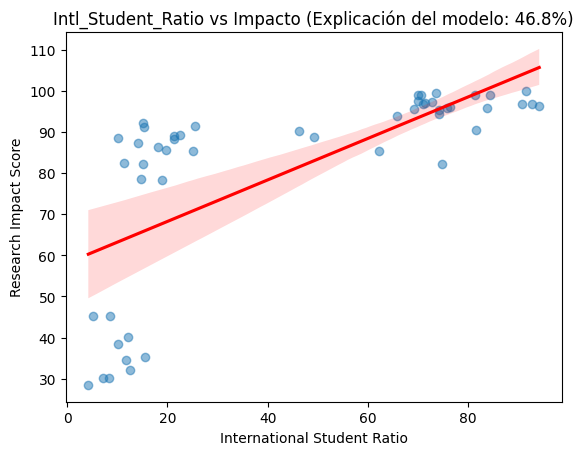

In [15]:
#Vamos a mirar la relación entre el "Intl_Student_Ratio" y el "research impact score"
plt.figure("Regresion entre Intl_Student_Ratio y reserarch impact score")
 
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Intl_Student_Ratio'], df['Research_Impact_Score'])
r_squared = r_value**2
 
sns.regplot(data=df, x='Intl_Student_Ratio', y='Research_Impact_Score', 
            scatter_kws={'alpha':0.5}, # Hace los puntos un poco transparentes
            line_kws={'color':'red', 'label': f"Regresión (R²={r_squared:.2f})"})  # Pone la línea de regresión en rojo
plt.title(f'Intl_Student_Ratio vs Impacto (Explicación del modelo: {r_squared:.1%})')
plt.xlabel('International Student Ratio')
plt.ylabel('Research Impact Score')

#Vemos que si bien hay alguna relación entre el porcentaje de estudiantes internacionales y el impacto de la investigación
#No es una relación muy fuerte (>70%)
#lo que sugiere que otros factores también juegan un papel importante en el impacto de la investigación de una universidad.

plt.show()